In [50]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import random
import cv2
import csv
import torchvision.transforms as transforms

# -----------------------------
# Model architecture (matches training)
# -----------------------------
class DownSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(DownSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

class UpSamplingBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(UpSamplingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.upsample(x)
        return x

class Autoencoder(nn.Module):
    def __init__(self, channels=[64, 128, 256], input_channels=3, output_channels=3):
        super().__init__()

        self.conv_in = nn.Conv2d(input_channels, channels[0], kernel_size=3, stride=1, padding=1)
        self.bn_in = nn.BatchNorm2d(channels[0])

        self.encoder_blocks = nn.ModuleList()
        for i in range(len(channels) - 1):
            self.encoder_blocks.append(DownSamplingBlock(channels[i], channels[i+1]))

        self.bottleneck = nn.Conv2d(channels[-1], channels[-1], kernel_size=3, stride=1, padding=1)
        self.bn_bottleneck = nn.BatchNorm2d(channels[-1])

        self.decoder_blocks = nn.ModuleList()
        for i in range(len(channels) - 1, 0, -1):
            self.decoder_blocks.append(UpSamplingBlock(channels[i], channels[i-1]))

        self.conv_out = nn.Conv2d(channels[0], output_channels, kernel_size=3, stride=1, padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = F.relu(self.bn_in(self.conv_in(x)))
        for block in self.encoder_blocks:
            x = block(x)
        x = F.relu(self.bn_bottleneck(self.bottleneck(x)))
        for block in self.decoder_blocks:
            x = block(x)
        x = self.sigmoid(self.conv_out(x))
        return x

# -----------------------------
# Inference Dataset (no noise)
# -----------------------------
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, gauss_noise=False, gauss_blur=False, resize=128, center_crop=128, p=0.0):
        self.p = p
        self.resize = resize
        self.gauss_noise = gauss_noise
        self.gauss_blur = gauss_blur
        self.center_crop = center_crop
        self.image_paths = image_paths
        self.transform = transforms.Compose([
            transforms.Resize((self.resize, self.resize)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        gt_image = Image.fromarray(image).resize((self.resize, self.resize))
        image = self.transform(gt_image)
        # For inference, we don't use labels; return dummy target identical to input
        return image, image

In [51]:
# -----------------------------
# Configurable model selection and loader
# -----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths inside Lab6_Hyperparameter-Tuning
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'data', 'test')
OUT_BASE = os.path.join(BASE_DIR, 'data')

# Available checkpoints
AUTOENC_PATH = os.path.join(BASE_DIR, 'autoencoder_model.pth')
GRID_PATH = os.path.join(BASE_DIR, 'best_grid_model.pth')
RANDOM_PATH = os.path.join(BASE_DIR, 'best_random_model.pth')
GRID_CSV = os.path.join(BASE_DIR, 'grid_search_results-lastday.csv')
RANDOM_CSV = os.path.join(BASE_DIR, 'random_search_results.csv')

# Models to run (set this list to subset if desired)
MODELS_TO_RUN = ['autoencoder_model', 'best_grid', 'best_random']

# If None, will auto-pick 128 for base model and 64 for grid/random (matches training)
DEFAULT_SIZE = None

def infer_arch_from_state_dict(state_dict):
    # Try to infer first conv out_channels to pick base width
    conv_in_keys = [k for k in state_dict.keys() if k.endswith('conv_in.weight')]
    if conv_in_keys:
        w = state_dict[conv_in_keys[0]]
        base = w.shape[0]  # out_channels of first conv
        # Build a conservative channel list by scanning encoder blocks
        chans = [base]
        # Look for encoder block conv weights to infer subsequent channels
        enc_convs = sorted([k for k in state_dict.keys() if 'encoder_blocks' in k and k.endswith('conv.weight')])
        for k in enc_convs:
            oc = state_dict[k].shape[0]
            if oc != chans[-1]:
                chans.append(oc)
        # Ensure monotonic increase typical in encoder
        chans = sorted(list(set(chans)))
        return chans if len(chans) >= 2 else [base, base*2, base*4]
    # Fallback to a common default
    return [64, 128, 256]

def load_model(preferred='autoencoder_model', resize=DEFAULT_SIZE):
    if preferred == 'autoencoder_model':
        ckpt_path = AUTOENC_PATH
        out_dir = os.path.join(OUT_BASE, 'denoised_results_auto')
        arch = None  # try default then infer
        if resize is None:
            resize = 128
    elif preferred == 'best_grid':
        ckpt_path = GRID_PATH
        out_dir = os.path.join(OUT_BASE, 'denoised_results_best_grid')
        arch = None
        if resize is None:
            resize = 64
        # Try parse best arch from CSV if available
        if os.path.exists(GRID_CSV):
            try:
                df = pd.read_csv(GRID_CSV)
                # Many Ray CSVs store config fields as strings like "[32, 64, 128]" under 'config/architecture'
                arch_col = None
                for c in df.columns:
                    if 'architecture' in c:
                        arch_col = c; break
                if arch_col is not None:
                    s = df.nsmallest(1, 'val_loss').iloc[0][arch_col]
                    if isinstance(s, str):
                        arch = [int(x) for x in s.strip('[]').replace(' ', '').split(',') if x]
                    elif isinstance(s, (list, tuple)):
                        arch = list(s)
            except Exception as e:
                print('Warning: could not parse GRID CSV for architecture:', e)
    elif preferred == 'best_random':
        ckpt_path = RANDOM_PATH
        out_dir = os.path.join(OUT_BASE, 'denoised_results_best_random')
        arch = None
        if resize is None:
            resize = 64
        if os.path.exists(RANDOM_CSV):
            try:
                df = pd.read_csv(RANDOM_CSV)
                arch_col = None
                for c in df.columns:
                    if 'architecture' in c:
                        arch_col = c; break
                if arch_col is not None:
                    s = df.nsmallest(1, 'val_loss').iloc[0][arch_col]
                    if isinstance(s, str):
                        arch = [int(x) for x in s.strip('[]').replace(' ', '').split(',') if x]
                    elif isinstance(s, (list, tuple)):
                        arch = list(s)
            except Exception as e:
                print('Warning: could not parse RANDOM CSV for architecture:', e)
    else:
        raise ValueError("preferred must be one of ['autoencoder_model', 'best_grid', 'best_random']")

    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')

    # Load state dict on CPU first for safety
    state = torch.load(ckpt_path, map_location='cpu')
    if isinstance(state, dict) and 'state_dict' in state:
        state_dict = state['state_dict']
    else:
        state_dict = state

    # If arch was not determined from CSV, try infer from weights
    if arch is None:
        arch = infer_arch_from_state_dict(state_dict)

    print(f'Using architecture: {arch} | input size: {resize}')
    model = Autoencoder(channels=arch).to(device)

    # Try strict load; if mismatch, relax and warn
    try:
        model.load_state_dict(state_dict, strict=True)
    except Exception as e:
        print('Strict load failed, retry non-strict:', e)
        missing, unexpected = model.load_state_dict(state_dict, strict=False)
        if missing or unexpected:
            print('Missing keys:', missing)
            print('Unexpected keys:', unexpected)

    model.eval()
    os.makedirs(out_dir, exist_ok=True)
    return model, out_dir, resize

# -----------------------------
# Run inference for all selected models
# -----------------------------
if os.path.exists(DATA_PATH):
    jpgs = [f for f in os.listdir(DATA_PATH) if f.lower().endswith('.jpg')]
    print(f"Found test directory with {len(jpgs)} images")
    test_files = jpgs
    test_paths = [os.path.join(DATA_PATH, f) for f in test_files]

    summary = []
    for model_name in MODELS_TO_RUN:
        print(f"\n=== Running inference with: {model_name} ===")
        model, output_dir, size = load_model(preferred=model_name, resize=DEFAULT_SIZE)
        dataset = CustomImageDataset(test_paths, gauss_noise=False, gauss_blur=False, resize=size, p=0.0)
        loader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=0)

        processed = 0
        with torch.no_grad():
            for batch_idx, (images, _) in enumerate(tqdm(loader, desc=f"Processing [{model_name}]")):
                images = images.to(device)
                outputs = model(images).cpu()
                for i in range(outputs.shape[0]):
                    if processed >= len(test_files):
                        break
                    out_img = torch.clamp(outputs[i], 0, 1)
                    out_np = out_img.permute(1, 2, 0).numpy()
                    out_pil = Image.fromarray((out_np * 255).astype('uint8'))
                    filename = test_files[processed]
                    out_path = os.path.join(output_dir, filename)
                    out_pil.save(out_path)
                    processed += 1

        print(f"✅ [{model_name}] Processed {processed} images and saved to '{output_dir}'")
        summary.append((model_name, output_dir, processed))

    print("\nSummary:")
    for name, out_dir, cnt in summary:
        print(f" - {name}: {cnt} files -> {out_dir}")
else:
    print(f"Test directory '{DATA_PATH}' not found. Put test jpg images in that folder and rerun.")

C:\Users\IMG_PRO\AppData\Local\Temp\ipykernel_4932\690348435.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location='cpu')


Found test directory with 1791 images

=== Running inference with: autoencoder_model ===
Using architecture: [64, 128, 256] | input size: 128


Processing [autoencoder_model]: 100%|██████████| 224/224 [00:03<00:00, 69.35it/s]
C:\Users\IMG_PRO\AppData\Local\Temp\ipykernel_4932\690348435.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this 

✅ [autoencoder_model] Processed 1791 images and saved to 'c:\Users\IMG_PRO\Desktop\Image-Processing-Course-2025\Lab6_Hyperparameter-Tuning\data\denoised_results_auto'

=== Running inference with: best_grid ===
Using architecture: [32, 64, 128] | input size: 64
Strict load failed, retry non-strict: Error(s) in loading state_dict for Autoencoder:
	Missing key(s) in state_dict: "conv_in.weight", "conv_in.bias", "bn_in.weight", "bn_in.bias", "bn_in.running_mean", "bn_in.running_var", "encoder_blocks.0.conv.weight", "encoder_blocks.0.conv.bias", "encoder_blocks.0.bn.weight", "encoder_blocks.0.bn.bias", "encoder_blocks.0.bn.running_mean", "encoder_blocks.0.bn.running_var", "encoder_blocks.1.conv.weight", "encoder_blocks.1.conv.bias", "encoder_blocks.1.bn.weight", "encoder_blocks.1.bn.bias", "encoder_blocks.1.bn.running_mean", "encoder_blocks.1.bn.running_var", "bottleneck.weight", "bottleneck.bias", "bn_bottleneck.weight", "bn_bottleneck.bias", "bn_bottleneck.running_mean", "bn_bottleneck.ru

Processing [best_grid]: 100%|██████████| 224/224 [00:01<00:00, 112.74it/s]
C:\Users\IMG_PRO\AppData\Local\Temp\ipykernel_4932\690348435.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experim

✅ [best_grid] Processed 1791 images and saved to 'c:\Users\IMG_PRO\Desktop\Image-Processing-Course-2025\Lab6_Hyperparameter-Tuning\data\denoised_results_best_grid'

=== Running inference with: best_random ===
Using architecture: [64, 128, 256] | input size: 64
Strict load failed, retry non-strict: Error(s) in loading state_dict for Autoencoder:
	Missing key(s) in state_dict: "conv_in.weight", "conv_in.bias", "bn_in.weight", "bn_in.bias", "bn_in.running_mean", "bn_in.running_var", "encoder_blocks.0.conv.weight", "encoder_blocks.0.conv.bias", "encoder_blocks.0.bn.weight", "encoder_blocks.0.bn.bias", "encoder_blocks.0.bn.running_mean", "encoder_blocks.0.bn.running_var", "encoder_blocks.1.conv.weight", "encoder_blocks.1.conv.bias", "encoder_blocks.1.bn.weight", "encoder_blocks.1.bn.bias", "encoder_blocks.1.bn.running_mean", "encoder_blocks.1.bn.running_var", "bottleneck.weight", "bottleneck.bias", "bn_bottleneck.weight", "bn_bottleneck.bias", "bn_bottleneck.running_mean", "bn_bottleneck.ru

Processing [best_random]: 100%|██████████| 224/224 [00:01<00:00, 113.25it/s]

✅ [best_random] Processed 1791 images and saved to 'c:\Users\IMG_PRO\Desktop\Image-Processing-Course-2025\Lab6_Hyperparameter-Tuning\data\denoised_results_best_random'

Summary:
 - autoencoder_model: 1791 files -> c:\Users\IMG_PRO\Desktop\Image-Processing-Course-2025\Lab6_Hyperparameter-Tuning\data\denoised_results_auto
 - best_grid: 1791 files -> c:\Users\IMG_PRO\Desktop\Image-Processing-Course-2025\Lab6_Hyperparameter-Tuning\data\denoised_results_best_grid
 - best_random: 1791 files -> c:\Users\IMG_PRO\Desktop\Image-Processing-Course-2025\Lab6_Hyperparameter-Tuning\data\denoised_results_best_random


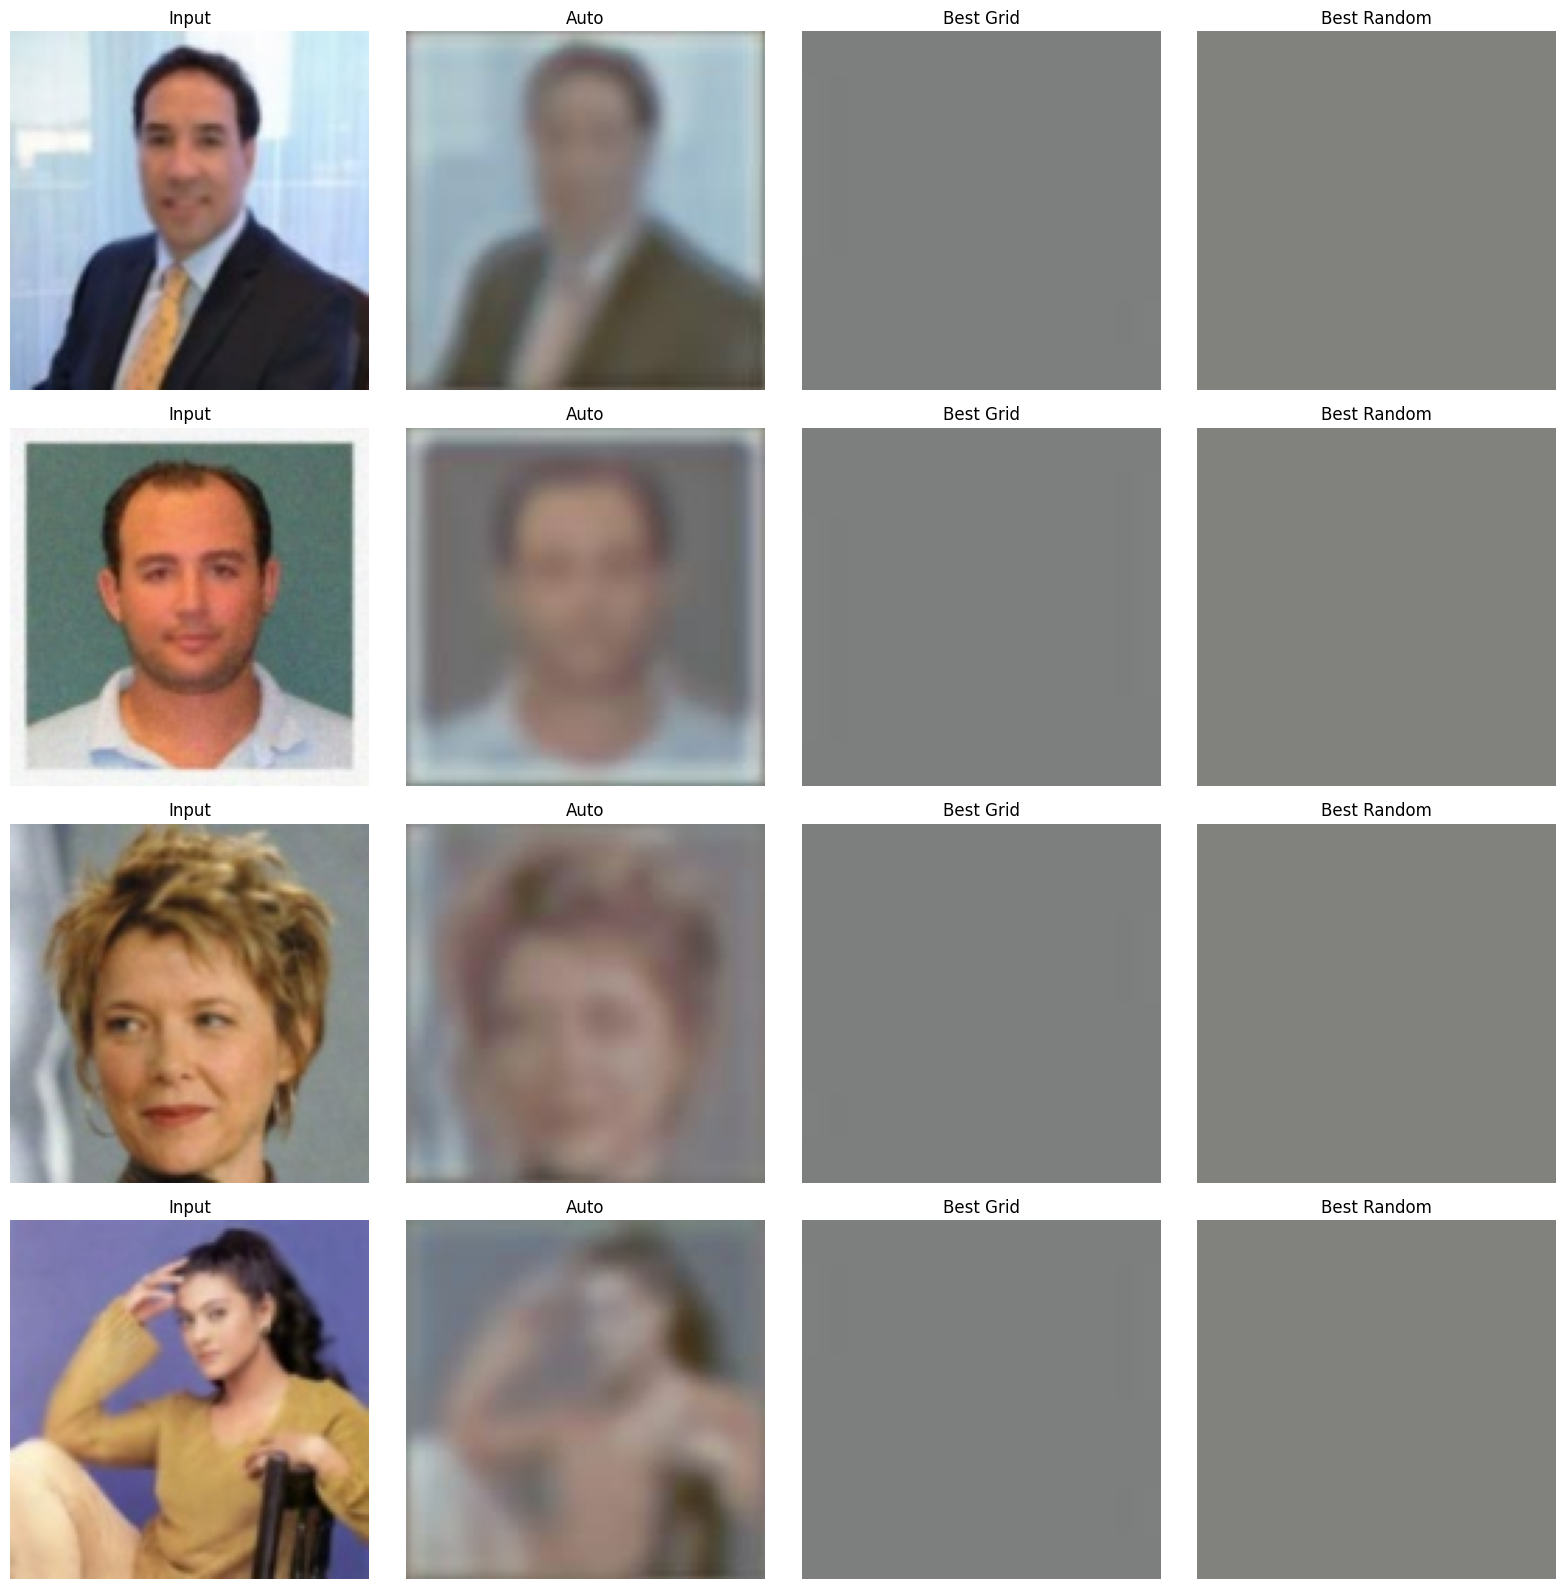

In [52]:
# -----------------------------
# Visualize a few results from all models
# -----------------------------
import matplotlib.pyplot as plt
from PIL import Image as PILImage

def load_img(path):
    im = PILImage.open(path).convert('RGB')
    return np.array(im)

def show_comparison(sample_files=None, max_show=4):
    base = OUT_BASE
    out_dirs = {
        'Input': os.path.join(BASE_DIR, 'data', 'test'),
        'Auto': os.path.join(base, 'denoised_results_auto'),
        'Grid': os.path.join(base, 'denoised_results_best_grid'),
        'Random': os.path.join(base, 'denoised_results_best_random'),
    }
    # Pick sample files
    inputs = [f for f in os.listdir(out_dirs['Input']) if f.lower().endswith('.jpg')]
    if not inputs:
        print('No input .jpg files found to visualize.')
        return
    files = sample_files if sample_files else inputs[:max_show]

    cols = 1 + 3  # input + three models
    rows = len(files)
    fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    if rows == 1:
        axs = np.expand_dims(axs, 0)
    for r, fname in enumerate(files):
        paths = [
            os.path.join(out_dirs['Input'], fname),
            os.path.join(out_dirs['Auto'], fname),
            os.path.join(out_dirs['Grid'], fname),
            os.path.join(out_dirs['Random'], fname),
        ]
        titles = ['Input', 'Auto', 'Best Grid', 'Best Random']
        for c, (p, t) in enumerate(zip(paths, titles)):
            if os.path.exists(p):
                img = load_img(p)
                axs[r, c].imshow(img)
                axs[r, c].set_title(t)
            else:
                axs[r, c].text(0.5, 0.5, 'Missing', ha='center', va='center')
                axs[r, c].set_title(t)
            axs[r, c].axis('off')
    plt.tight_layout()
    plt.show()

# Call this to preview up to 4 samples
show_comparison(max_show=4)